In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator
import os

# Configuration
trial_path = "../../data/08-30_dataset/08-30_dp_experiments/08-30_dp_trial_07/"

def load_trajectory_data(trial_path):
    """Load trajectory data from CSV file."""
    trajectory_file = os.path.join(trial_path, "trajectory_data.csv")
    
    if not os.path.exists(trajectory_file):
        raise FileNotFoundError(f"Trajectory file not found: {trajectory_file}")
    
    # Read CSV
    df = pd.read_csv(trajectory_file)
    
    # Extract relevant columns
    data = {
        'time': df['ros_time_sec'].values,
        'des_ross_x': df['des_ross_x'].values,
        'des_ross_y': df['des_ross_y'].values, 
        'des_ross_theta': df['des_ross_theta'].values,
        'des_mon_x': df['des_mon_x'].values,
        'des_mon_y': df['des_mon_y'].values,
        'des_mon_theta': df['des_mon_theta'].values,
        'act_ross_x': df['act_ross_x'].values,
        'act_ross_y': df['act_ross_y'].values,
        'act_ross_theta': df['act_ross_theta'].values,
        'act_mon_x': df['act_mon_x'].values,
        'act_mon_y': df['act_mon_y'].values,
        'act_mon_theta': df['act_mon_theta'].values,
        'act_payload_x': df['act_payload_x'].values,
        'act_payload_y': df['act_payload_y'].values,
        'act_payload_theta': df['act_payload_theta'].values
    }
    
    return data

def animate_desired_paths(trial_path, 
                         fps=30,
                         duration_s=30.0,        # Total animation duration in seconds
                         robot_width=0.24,       # Width of robot rectangles (3x original)
                         robot_height=0.16,      # Height of robot rectangles (2x original)  
                         arrow_length=0.12,      # Length of axis arrows
                         save_gif=None,
                         show=True):
    """
    Animation 1: Desired paths with rotating frame diagrams.
    Shows Ross and Monica with rotating rectangles and labeled x/y axes.
    Includes connection lines between robots.
    
    Parameters:
    - duration_s: Total animation duration in seconds (default 30s)
    - robot_width: Width of robot rectangles (default 0.24m)
    - robot_height: Height of robot rectangles (default 0.16m)
    """
    
    # Load data
    data = load_trajectory_data(trial_path)
    
    # Extract arrays
    t = data['time']
    ross_x = data['des_ross_x']
    ross_y = data['des_ross_y'] 
    ross_theta = data['des_ross_theta']
    mon_x = data['des_mon_x']
    mon_y = data['des_mon_y']
    mon_theta = data['des_mon_theta']
    
    N_full = len(t)
    if N_full < 2:
        raise ValueError("Not enough data points to animate.")
    
    # Calculate frame_step to achieve desired duration
    total_frames_needed = int(duration_s * fps)
    frame_step = max(1, N_full // total_frames_needed)
    
    # Frame decimation
    k_idx = np.arange(0, N_full, frame_step, dtype=int)
    if k_idx[-1] != N_full - 1:
        k_idx = np.append(k_idx, N_full - 1)
    
    # Decimated arrays
    tA = t[k_idx]
    ross_xA = ross_x[k_idx]
    ross_yA = ross_y[k_idx]
    ross_thetaA = ross_theta[k_idx]
    mon_xA = mon_x[k_idx] 
    mon_yA = mon_y[k_idx]
    mon_thetaA = mon_theta[k_idx]
    N = len(k_idx)
    
    # Setup figure - twice as big
    fig, ax = plt.subplots(figsize=(15, 12))
    ax.set_aspect('equal', adjustable='box')
    
    # Plot static paths (desired paths - bolder)
    ax.plot(ross_x, ross_y, color='tab:blue', lw=2.5, alpha=0.6, label='Ross desired path')
    ax.plot(mon_x, mon_y, color='tab:red', lw=2.5, alpha=0.6, label='Monica desired path')
    
    # Set limits with padding of 0.2 for both axes and equal tick spacing
    all_x = np.concatenate([ross_x, mon_x])
    all_y = np.concatenate([ross_y, mon_y])
    
    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    
    padding = 0.2
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    
    # Set equal tick spacing of 0.5m for both axes
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X Position [m]', fontsize=16)
    ax.set_ylabel('Y Position [m]', fontsize=16)
    ax.set_title('Optimal Trajectory Planner', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.legend(fontsize=14)
    
    # Create animated elements
    # Ross rectangle and axes (hollow rectangle)
    ross_rect = Rectangle((0, 0), robot_width, robot_height, 
                         angle=0, fill=False, edgecolor='black', linewidth=4, animated=True)
    ax.add_patch(ross_rect)
    
    # Ross axes arrows
    (ross_x_arrow,) = ax.plot([], [], 'r-', lw=3, animated=True)  # X-axis red
    (ross_y_arrow,) = ax.plot([], [], 'g-', lw=3, animated=True)  # Y-axis green
    ross_x_text = ax.text(0, 0, 'x', color='red', fontsize=18, ha='center', va='center', 
                         animated=True)
    ross_y_text = ax.text(0, 0, 'y', color='green', fontsize=18, ha='center', va='center', 
                         animated=True)
    ross_name_text = ax.text(0, 0, 'Ross', color='blue', fontsize=16, ha='center', va='center', 
                            animated=True)
    
    # Monica rectangle and axes (hollow rectangle)
    mon_rect = Rectangle((0, 0), robot_width, robot_height,
                        angle=0, fill=False, edgecolor='black', linewidth=4, animated=True)
    ax.add_patch(mon_rect)
    
    # Monica axes arrows
    (mon_x_arrow,) = ax.plot([], [], 'r-', lw=3, animated=True)   # X-axis red
    (mon_y_arrow,) = ax.plot([], [], 'g-', lw=3, animated=True)   # Y-axis green
    mon_x_text = ax.text(0, 0, 'x', color='red', fontsize=18, ha='center', va='center', 
                        animated=True)
    mon_y_text = ax.text(0, 0, 'y', color='green', fontsize=18, ha='center', va='center', 
                        animated=True)
    mon_name_text = ax.text(0, 0, 'Monica', color='red', fontsize=16, ha='center', va='center',
                           animated=True)
    
    # Connection lines between robots
    (ross_connection,) = ax.plot([], [], '-', color='purple', lw=4, animated=True)
    (monica_connection,) = ax.plot([], [], '-', color='orange', lw=4, animated=True)
    
    # Trails (removed as requested)
    # (ross_trail,) = ax.plot([], [], '-', color='tab:blue', lw=2, alpha=0.8, animated=True)
    # (mon_trail,) = ax.plot([], [], '-', color='tab:red', lw=2, alpha=0.8, animated=True)
    
    # All animated artists
    artists_all = [ross_rect, ross_x_arrow, ross_y_arrow, 
                   mon_rect, mon_x_arrow, mon_y_arrow,
                   ross_x_text, ross_y_text, ross_name_text,
                   mon_x_text, mon_y_text, mon_name_text,
                   ross_connection, monica_connection]
    
    def init():
        """Initialize animation."""
        for artist in artists_all:
            if hasattr(artist, 'set_data'):
                artist.set_data([], [])
            elif hasattr(artist, 'set_text'):
                artist.set_text('')
            elif hasattr(artist, 'set_position'):
                artist.set_position((0, 0))
        # Make sure text is visible initially
        ross_x_text.set_text('x')
        ross_y_text.set_text('y')
        ross_name_text.set_text('Ross')
        mon_x_text.set_text('x')
        mon_y_text.set_text('y')
        mon_name_text.set_text('Monica')
        return artists_all
    
    def animate_frame(i):
        """Animate single frame."""
        k = i
        
        # Ross position and orientation
        rx, ry, rtheta = ross_xA[k], ross_yA[k], ross_thetaA[k]
        
        # Update Ross rectangle - properly centered rotation
        # For matplotlib Rectangle, we need to account for rotation around bottom-left corner
        cos_r, sin_r = np.cos(rtheta), np.sin(rtheta)
        
        # Calculate offset to center rectangle after rotation
        dx = -robot_width/2 * cos_r + robot_height/2 * sin_r
        dy = -robot_width/2 * sin_r - robot_height/2 * cos_r
        ross_rect.set_xy((rx + dx, ry + dy))
        ross_rect.angle = np.degrees(rtheta)
        
        # Ross coordinate frame arrows
        # X-axis arrow (red)
        rx_end = rx + arrow_length * cos_r
        ry_end = ry + arrow_length * sin_r
        ross_x_arrow.set_data([rx, rx_end], [ry, ry_end])
        
        # Y-axis arrow (green) - rotated 90 degrees from x-axis
        ry_x_end = rx - arrow_length * sin_r  # 90 degree rotation
        ry_y_end = ry + arrow_length * cos_r
        ross_y_arrow.set_data([rx, ry_x_end], [ry, ry_y_end])
        
        # Ross text labels - positioned further out for visibility
        ross_x_text.set_position((rx_end + 0.08, ry_end + 0.02))
        ross_y_text.set_position((ry_x_end - 0.08, ry_y_end + 0.02))
        ross_name_text.set_position((rx - 0.18 * sin_r, ry - 0.18 * cos_r))
        
        # Monica position and orientation
        mx, my, mtheta = mon_xA[k], mon_yA[k], mon_thetaA[k]
        
        # Update Monica rectangle - properly centered rotation
        cos_m, sin_m = np.cos(mtheta), np.sin(mtheta)
        
        # Calculate offset to center rectangle after rotation
        dx_m = -robot_width/2 * cos_m + robot_height/2 * sin_m
        dy_m = -robot_width/2 * sin_m - robot_height/2 * cos_m
        mon_rect.set_xy((mx + dx_m, my + dy_m))
        mon_rect.angle = np.degrees(mtheta)
        
        # Monica coordinate frame arrows
        # X-axis arrow (red)
        mx_end = mx - arrow_length * cos_m
        my_end = my - arrow_length * sin_m
        mon_x_arrow.set_data([mx, mx_end], [my, my_end])
        
        # Y-axis arrow (green)
        my_x_end = mx + arrow_length * sin_m
        my_y_end = my - arrow_length * cos_m
        mon_y_arrow.set_data([mx, my_x_end], [my, my_y_end])
        
        # Monica text labels - positioned further out for visibility
        mon_x_text.set_position((mx_end + 0.08, my_end + 0.02))
        mon_y_text.set_position((my_x_end - 0.08, my_y_end + 0.02))
        mon_name_text.set_position((mx - 0.18 * sin_m, my - 0.18 * cos_m))
        
        # Connection lines between robots
        # Calculate side centers accounting for rotation
        # Ross right side center (in global coordinates)
        ross_right_x = rx + robot_width/2 * cos_r
        ross_right_y = ry + robot_width/2 * sin_r
        
        # Monica left side center (in global coordinates) 
        monica_left_x = mx - robot_width/2 * cos_m
        monica_left_y = my - robot_width/2 * sin_m
        
        # Direction vector from Ross to Monica
        dx_conn = monica_left_x - ross_right_x
        dy_conn = monica_left_y - ross_right_y
        dist = np.sqrt(dx_conn**2 + dy_conn**2)
        
        if dist > 0:  # Avoid division by zero
            # Normalized direction
            dx_norm = dx_conn / dist
            dy_norm = dy_conn / dist
            
            # Line length - shorter than robot height
            line_length = robot_height * 0.7
            
            # Ross connection line: from right side toward Monica
            ross_conn_end_x = ross_right_x + line_length * dx_norm
            ross_conn_end_y = ross_right_y + line_length * dy_norm
            ross_connection.set_data([ross_right_x, ross_conn_end_x], [ross_right_y, ross_conn_end_y])
            
            # Monica connection line: from left side toward Ross
            monica_conn_end_x = monica_left_x - line_length * dx_norm
            monica_conn_end_y = monica_left_y - line_length * dy_norm
            monica_connection.set_data([monica_left_x, monica_conn_end_x], [monica_left_y, monica_conn_end_y])
                
        else:
            # If robots are at same position, don't draw lines
            ross_connection.set_data([], [])
            monica_connection.set_data([], [])
        
        # Update trails (removed as requested)
        # k0 = max(0, k - trail_frames)
        # ross_trail.set_data(ross_xA[k0:k+1], ross_yA[k0:k+1])
        # mon_trail.set_data(mon_xA[k0:k+1], mon_yA[k0:k+1])
        
        return artists_all
    
    # Create animation
    interval_ms = 1000.0 / float(fps)
    anim = animation.FuncAnimation(
        fig, animate_frame, init_func=init,
        frames=N, interval=interval_ms, blit=True, repeat=True
    )
    
    # Save GIF if requested
    if save_gif:
        try:
            anim.save(save_gif, writer="pillow", fps=fps)
            print(f"Animation saved to: {save_gif}")
        except Exception as e:
            print(f"[WARN] Failed to save GIF to '{save_gif}': {e}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return anim


Animation saved to: figures/animation1_desired_paths.gif


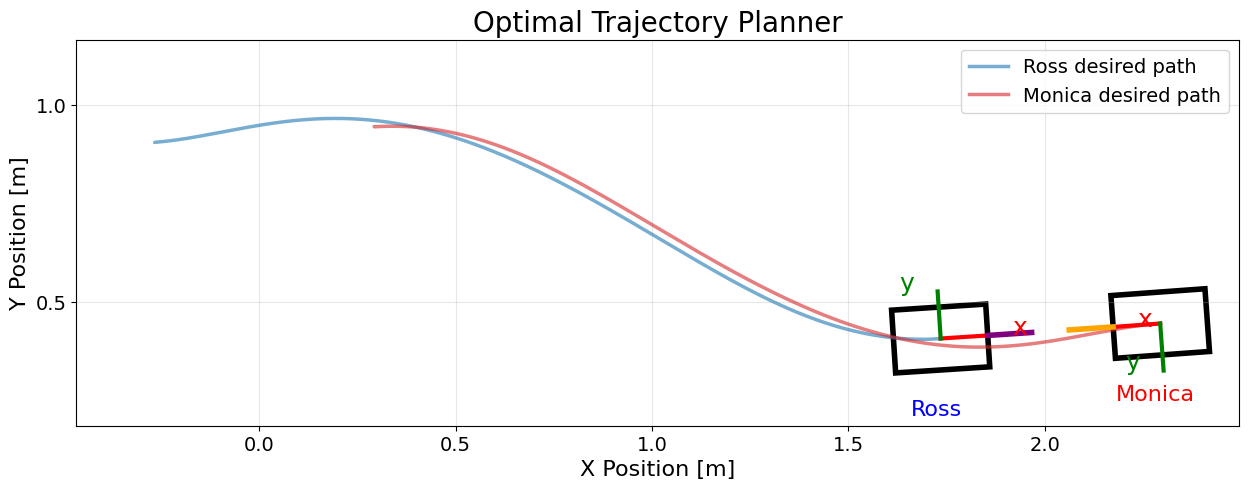

In [48]:
# Update the trial_path to your actual data location
trial_path = "../../data/08-30_dataset/08-30_dp_experiments/08-30_dp_trial_07/"

# Run Animation 1
anim1 = animate_desired_paths(trial_path, fps=10, show=True, save_gif="figures/animation1_desired_paths.gif", duration_s=30.0)

In [49]:
def animate_actual_vs_desired(trial_path, 
                              fps=30,
                              duration_s=30.0,        # Total animation duration in seconds
                              save_gif=None,
                              show=True):
    """
    Animation 2: Actual vs Desired paths comparison.
    Shows Ross and Monica desired (dotted) vs actual (solid) paths,
    plus payload actual path. Paths are drawn progressively over time.
    
    Parameters:
    - duration_s: Total animation duration in seconds (default 30s)
    """
    
    # Load data (reuse the function from Animation 1)
    data = load_trajectory_data(trial_path)
    
    # Extract arrays
    t = data['time']
    # Desired paths
    des_ross_x = data['des_ross_x']
    des_ross_y = data['des_ross_y'] 
    des_mon_x = data['des_mon_x']
    des_mon_y = data['des_mon_y']
    # Actual paths
    act_ross_x = data['act_ross_x']
    act_ross_y = data['act_ross_y']
    act_mon_x = data['act_mon_x']
    act_mon_y = data['act_mon_y']
    act_payload_x = data['act_payload_x']
    act_payload_y = data['act_payload_y']
    
    N_full = len(t)
    if N_full < 2:
        raise ValueError("Not enough data points to animate.")
    
    # Calculate frame_step to achieve desired duration
    total_frames_needed = int(duration_s * fps)
    frame_step = max(1, N_full // total_frames_needed)
    
    # Frame decimation
    k_idx = np.arange(0, N_full, frame_step, dtype=int)
    if k_idx[-1] != N_full - 1:
        k_idx = np.append(k_idx, N_full - 1)
    
    # Decimated arrays
    tA = t[k_idx]
    des_ross_xA = des_ross_x[k_idx]
    des_ross_yA = des_ross_y[k_idx]
    des_mon_xA = des_mon_x[k_idx]
    des_mon_yA = des_mon_y[k_idx]
    act_ross_xA = act_ross_x[k_idx]
    act_ross_yA = act_ross_y[k_idx]
    act_mon_xA = act_mon_x[k_idx]
    act_mon_yA = act_mon_y[k_idx]
    act_payload_xA = act_payload_x[k_idx]
    act_payload_yA = act_payload_y[k_idx]
    N = len(k_idx)
    
    # Setup figure - same size as Animation 1
    fig, ax = plt.subplots(figsize=(20, 16))
    ax.set_aspect('equal', adjustable='box')
    
    # Set limits with padding of 0.2 for both axes and equal tick spacing
    all_x = np.concatenate([des_ross_x, des_mon_x, act_ross_x, act_mon_x, act_payload_x])
    all_y = np.concatenate([des_ross_y, des_mon_y, act_ross_y, act_mon_y, act_payload_y])
    
    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    
    padding = 0.2
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    
    # Set equal tick spacing of 0.5m for both axes
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X Position [m]', fontsize=16)
    ax.set_ylabel('Y Position [m]', fontsize=16)
    ax.set_title('Actual vs Desired Trajectory Comparison', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Create animated path lines (progressive drawing)
    # Desired paths (dotted)
    (des_ross_path,) = ax.plot([], [], '--', color='lightblue', lw=3, alpha=0.8, 
                               animated=True, label='Ross desired')
    (des_mon_path,) = ax.plot([], [], '--', color='lightcoral', lw=3, alpha=0.8, 
                              animated=True, label='Monica desired')
    
    # Actual paths (solid)
    (act_ross_path,) = ax.plot([], [], '-', color='blue', lw=3, 
                               animated=True, label='Ross actual')
    (act_mon_path,) = ax.plot([], [], '-', color='red', lw=3, 
                              animated=True, label='Monica actual')
    (act_payload_path,) = ax.plot([], [], '-', color='green', lw=3, 
                                  animated=True, label='Payload actual')
    
    # Current position dots
    (des_ross_dot,) = ax.plot([], [], 'o', color='lightblue', ms=8, animated=True)
    (des_mon_dot,) = ax.plot([], [], 'o', color='lightcoral', ms=8, animated=True)
    (act_ross_dot,) = ax.plot([], [], 'o', color='blue', ms=10, animated=True)
    (act_mon_dot,) = ax.plot([], [], 'o', color='red', ms=10, animated=True)
    (act_payload_dot,) = ax.plot([], [], 'o', color='green', ms=10, animated=True)
    
    # Legend
    ax.legend(fontsize=14, loc='upper right')
    
    # All animated artists
    artists_all = [des_ross_path, des_mon_path, act_ross_path, act_mon_path, act_payload_path,
                   des_ross_dot, des_mon_dot, act_ross_dot, act_mon_dot, act_payload_dot]
    
    def init():
        """Initialize animation."""
        for artist in artists_all:
            if hasattr(artist, 'set_data'):
                artist.set_data([], [])
        return artists_all
    
    def animate_frame(i):
        """Animate single frame - progressive path drawing."""
        k = i
        
        # Draw paths up to current frame (progressive building)
        # Desired paths (dotted lines)
        des_ross_path.set_data(des_ross_xA[0:k+1], des_ross_yA[0:k+1])
        des_mon_path.set_data(des_mon_xA[0:k+1], des_mon_yA[0:k+1])
        
        # Actual paths (solid lines)
        act_ross_path.set_data(act_ross_xA[0:k+1], act_ross_yA[0:k+1])
        act_mon_path.set_data(act_mon_xA[0:k+1], act_mon_yA[0:k+1])
        act_payload_path.set_data(act_payload_xA[0:k+1], act_payload_yA[0:k+1])
        
        # Current position dots
        des_ross_dot.set_data([des_ross_xA[k]], [des_ross_yA[k]])
        des_mon_dot.set_data([des_mon_xA[k]], [des_mon_yA[k]])
        act_ross_dot.set_data([act_ross_xA[k]], [act_ross_yA[k]])
        act_mon_dot.set_data([act_mon_xA[k]], [act_mon_yA[k]])
        act_payload_dot.set_data([act_payload_xA[k]], [act_payload_yA[k]])
        
        return artists_all
    
    # Create animation
    interval_ms = 1000.0 / float(fps)
    anim = animation.FuncAnimation(
        fig, animate_frame, init_func=init,
        frames=N, interval=interval_ms, blit=True, repeat=True
    )
    
    # Save GIF if requested
    if save_gif:
        try:
            anim.save(save_gif, writer="pillow", fps=fps)
            print(f"Animation saved to: {save_gif}")
        except Exception as e:
            print(f"[WARN] Failed to save GIF to '{save_gif}': {e}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return anim

Animation saved to: figures/animation2_actual_vs_desired.gif


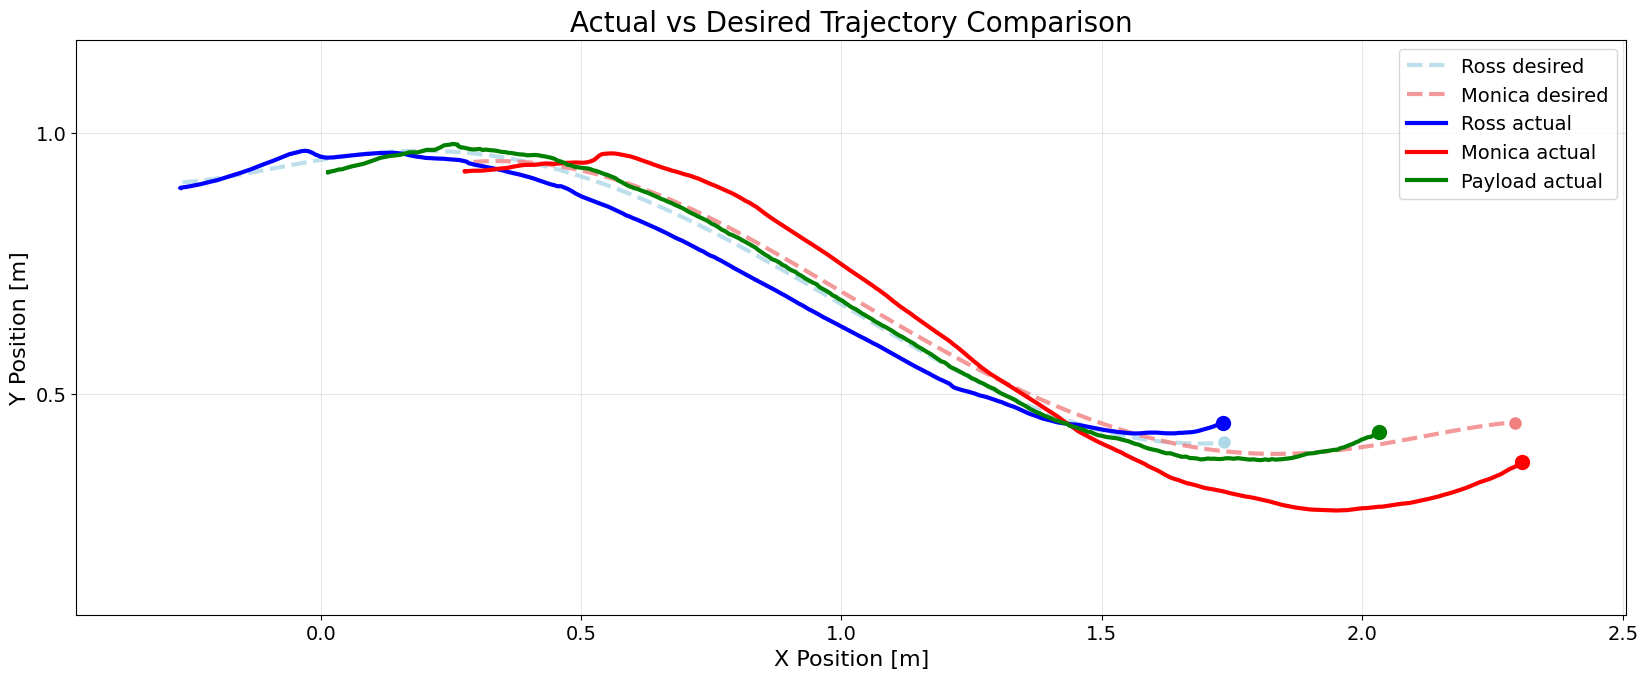

In [50]:
anim2 = animate_actual_vs_desired(trial_path, fps=10, duration_s=30, show=True, save_gif="figures/animation2_actual_vs_desired.gif")

In [51]:
def load_force_data(trial_path):
    """Load force data from both admittance CSV files, cropped to cmd_vel timerange."""
    ross_file = os.path.join(trial_path, "ross_admittance_data.csv")
    monica_file = os.path.join(trial_path, "monica_admittance_data.csv")
    trajectory_file = os.path.join(trial_path, "trajectory_data.csv")
    
    if not os.path.exists(ross_file):
        raise FileNotFoundError(f"Ross admittance file not found: {ross_file}")
    if not os.path.exists(monica_file):
        raise FileNotFoundError(f"Monica admittance file not found: {monica_file}")
    if not os.path.exists(trajectory_file):
        raise FileNotFoundError(f"Trajectory file not found: {trajectory_file}")
    
    # Load trajectory data to find cmd_vel time range
    traj_df = pd.read_csv(trajectory_file)
    
    # Find first and last non-zero/non-NaN cmd_vel entries
    cmd_vel_cols = ['ross_cmd_vel_linear_x', 'ross_cmd_vel_angular_z', 
                    'monica_cmd_vel_linear_x', 'monica_cmd_vel_angular_z']
    
    # Create mask for any non-zero cmd_vel
    cmd_vel_mask = pd.Series(False, index=traj_df.index)
    for col in cmd_vel_cols:
        if col in traj_df.columns:
            # Consider non-zero and non-NaN as active command
            col_mask = (traj_df[col] != 0) & (~traj_df[col].isna())
            cmd_vel_mask = cmd_vel_mask | col_mask
    
    # Find first and last cmd_vel timestamps
    if cmd_vel_mask.any():
        first_cmd_idx = cmd_vel_mask.idxmax()  # First True index
        last_cmd_idx = cmd_vel_mask[::-1].idxmax()  # Last True index (reverse search)
        
        cmd_start_time = traj_df.loc[first_cmd_idx, 'ros_time_sec']
        cmd_end_time = traj_df.loc[last_cmd_idx, 'ros_time_sec']
        
        print(f"Command velocity active from {cmd_start_time:.3f}s to {cmd_end_time:.3f}s")
    else:
        print("Warning: No non-zero cmd_vel found, using full force data range")
        cmd_start_time = -np.inf
        cmd_end_time = np.inf
    
    # Read force CSVs
    ross_df = pd.read_csv(ross_file)
    monica_df = pd.read_csv(monica_file)
    
    # Crop force data to cmd_vel time range
    ross_time_mask = ((ross_df['ros_time_sec'] >= cmd_start_time) & 
                      (ross_df['ros_time_sec'] <= cmd_end_time))
    monica_time_mask = ((monica_df['ros_time_sec'] >= cmd_start_time) & 
                        (monica_df['ros_time_sec'] <= cmd_end_time))
    
    ross_df_cropped = ross_df[ross_time_mask]
    monica_df_cropped = monica_df[monica_time_mask]
    
    # Decimate data - take every other point for faster rendering
    ross_df_decimated = ross_df_cropped.iloc[::2]
    monica_df_decimated = monica_df_cropped.iloc[::2]
    
    print(f"Ross force data: {len(ross_df_decimated)} points (was {len(ross_df)}, cropped to {len(ross_df_cropped)})")
    print(f"Monica force data: {len(monica_df_decimated)} points (was {len(monica_df)}, cropped to {len(monica_df_cropped)})")
    
    # Extract relevant columns
    force_data = {
        'ross_time': ross_df_decimated['ros_time_sec'].values,
        'ross_force': ross_df_decimated['force'].values,
        'monica_time': monica_df_decimated['ros_time_sec'].values,
        'monica_force': monica_df_decimated['force'].values,
        'cmd_start_time': cmd_start_time,
        'cmd_end_time': cmd_end_time
    }
    
    return force_data

def animate_force_over_time(trial_path, 
                           fps=30,
                           duration_s=30.0,        # Total animation duration in seconds
                           save_gif=None,
                           show=True):
    """
    Animation 3: Force over time progression.
    Shows Ross and Monica force measurements building up over time.
    
    Parameters:
    - duration_s: Total animation duration in seconds (default 30s)
    """
    
    # Load force data
    force_data = load_force_data(trial_path)
    
    # Extract arrays
    ross_time = force_data['ross_time']
    ross_force = force_data['ross_force']
    monica_time = force_data['monica_time']
    monica_force = force_data['monica_force']
    
    # Find the data with more points to use as reference
    if len(ross_time) >= len(monica_time):
        ref_time = ross_time
        N_full = len(ross_time)
    else:
        ref_time = monica_time
        N_full = len(monica_time)
    
    if N_full < 2:
        raise ValueError("Not enough data points to animate.")
    
    # Calculate frame_step to achieve desired duration
    total_frames_needed = int(duration_s * fps)
    frame_step = max(1, N_full // total_frames_needed)
    
    # Frame decimation for reference time
    k_idx = np.arange(0, N_full, frame_step, dtype=int)
    if k_idx[-1] != N_full - 1:
        k_idx = np.append(k_idx, N_full - 1)
    
    N = len(k_idx)
    
    # Setup figure - adjusted size for force plots
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Calculate time and force ranges for all data
    all_times = np.concatenate([ross_time, monica_time])
    all_forces = np.concatenate([ross_force, monica_force])
    
    time_min, time_max = np.min(all_times), np.max(all_times)
    force_min, force_max = np.min(all_forces), np.max(all_forces)
    
    # Add padding to ranges
    time_padding = (time_max - time_min) * 0.05  # 5% padding for time
    force_padding = (force_max - force_min) * 0.1  # 10% padding for force
    
    ax.set_xlim(time_min - time_padding, time_max + time_padding)
    ax.set_ylim(force_min - force_padding, force_max + force_padding)
    
    # Grid and labels
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Time [s]', fontsize=16)
    ax.set_ylabel('Force [N]', fontsize=16)
    ax.set_title('Force Measurements Over Time', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Create animated force lines (progressive drawing)
    (ross_force_line,) = ax.plot([], [], '-', color='blue', lw=3, 
                                animated=True, label='Ross force')
    (monica_force_line,) = ax.plot([], [], '-', color='red', lw=3, 
                                  animated=True, label='Monica force')
    
    # Current force dots
    (ross_force_dot,) = ax.plot([], [], 'o', color='blue', ms=10, animated=True)
    (monica_force_dot,) = ax.plot([], [], 'o', color='red', ms=10, animated=True)
    
    # Legend
    ax.legend(fontsize=14, loc='upper right')
    
    # All animated artists
    artists_all = [ross_force_line, monica_force_line, ross_force_dot, monica_force_dot]
    
    def init():
        """Initialize animation."""
        for artist in artists_all:
            if hasattr(artist, 'set_data'):
                artist.set_data([], [])
        return artists_all
    
    def animate_frame(i):
        """Animate single frame - progressive force plot drawing."""
        k = k_idx[i]
        
        # Current time (using reference time)
        current_time = ref_time[k]
        
        # Find data points up to current time for Ross
        ross_mask = ross_time <= current_time
        if np.any(ross_mask):
            ross_time_current = ross_time[ross_mask]
            ross_force_current = ross_force[ross_mask]
            ross_force_line.set_data(ross_time_current, ross_force_current)
            
            # Current Ross force dot
            if len(ross_time_current) > 0:
                ross_force_dot.set_data([ross_time_current[-1]], [ross_force_current[-1]])
            else:
                ross_force_dot.set_data([], [])
        else:
            ross_force_line.set_data([], [])
            ross_force_dot.set_data([], [])
        
        # Find data points up to current time for Monica
        monica_mask = monica_time <= current_time
        if np.any(monica_mask):
            monica_time_current = monica_time[monica_mask]
            monica_force_current = monica_force[monica_mask]
            monica_force_line.set_data(monica_time_current, monica_force_current)
            
            # Current Monica force dot
            if len(monica_time_current) > 0:
                monica_force_dot.set_data([monica_time_current[-1]], [monica_force_current[-1]])
            else:
                monica_force_dot.set_data([], [])
        else:
            monica_force_line.set_data([], [])
            monica_force_dot.set_data([], [])
        
        return artists_all
    
    # Create animation
    interval_ms = 1000.0 / float(fps)
    anim = animation.FuncAnimation(
        fig, animate_frame, init_func=init,
        frames=N, interval=interval_ms, blit=True, repeat=True
    )
    
    # Save GIF if requested
    if save_gif:
        try:
            anim.save(save_gif, writer="pillow", fps=fps)
            print(f"Animation saved to: {save_gif}")
        except Exception as e:
            print(f"[WARN] Failed to save GIF to '{save_gif}': {e}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return anim

Command velocity active from 1756586507.269s to 1756586537.261s
Ross force data: 7498 points (was 29105, cropped to 14996)
Monica force data: 7498 points (was 26477, cropped to 14995)
Animation saved to: figures/animation3_force_over_time.gif


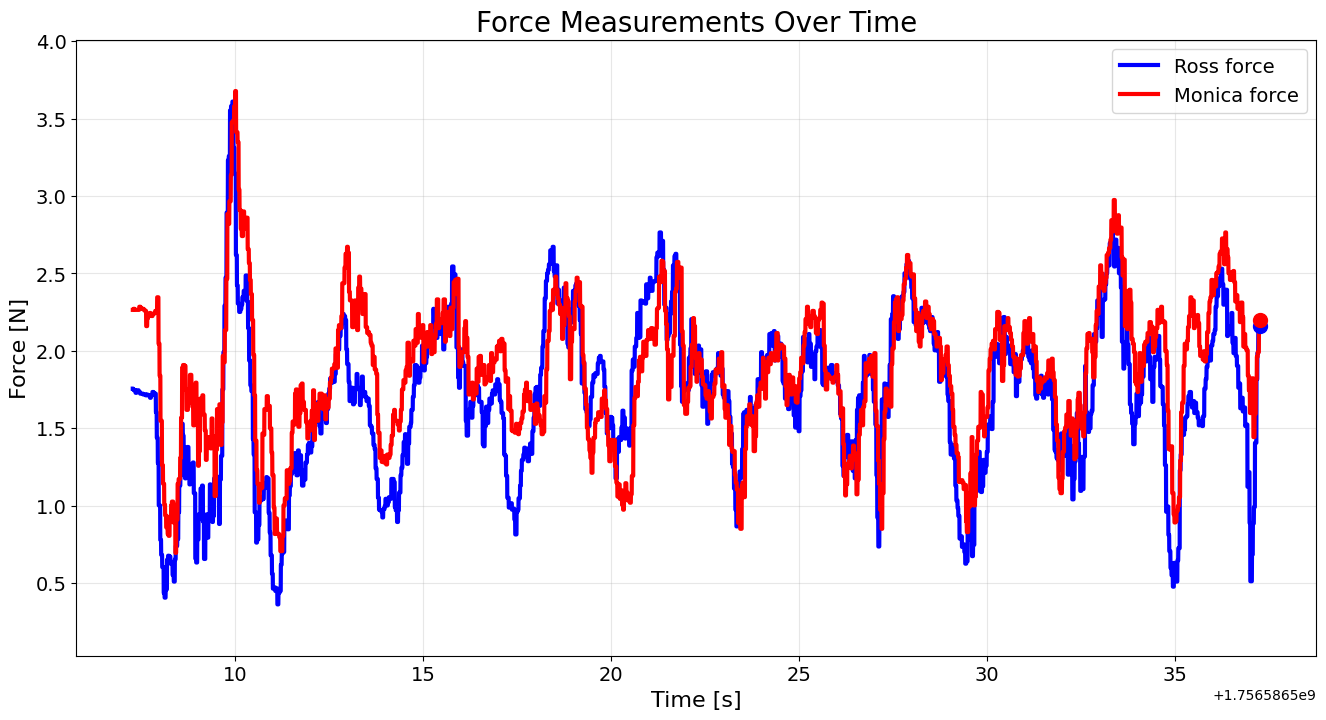

In [52]:
anim3 = animate_force_over_time(trial_path, fps=10, duration_s=30, show=True, save_gif="figures/animation3_force_over_time.gif")